In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scheme_perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
investor_txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

print("Scheme Performance Shape:", scheme_perf.shape)
print("Investor Transactions Shape:", investor_txn.shape)
print("Portfolio Holdings Shape:", portfolio.shape)

Scheme Performance Shape: (40, 19)
Investor Transactions Shape: (32778, 13)
Portfolio Holdings Shape: (322, 8)


In [2]:
print("Scheme Performance Columns:")
print(scheme_perf.columns.tolist())

print("\nInvestor Transaction Columns:")
print(investor_txn.columns.tolist())

print("\nPortfolio Columns:")
print(portfolio.columns.tolist())

Scheme Performance Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Investor Transaction Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Portfolio Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [3]:
var_cvar = []

for _, row in scheme_perf.iterrows():

    returns = np.array([
        row['return_1yr_pct'],
        row['return_3yr_pct'],
        row['return_5yr_pct']
    ])

    returns = returns[~pd.isna(returns)]

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar.append([
        row['amfi_code'],
        row['scheme_name'],
        var_95,
        cvar_95
    ])

var_cvar_report = pd.DataFrame(
    var_cvar,
    columns=['amfi_code','scheme_name','VaR_95','CVaR_95']
)

var_cvar_report.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.366,12.36
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.593,11.30
2,119598,SBI Small Cap Fund - Regular Plan - Growth,20.942,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.713,20.59
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.349,5.34


In [4]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


In [5]:
scheme_perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [6]:
scheme_perf.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

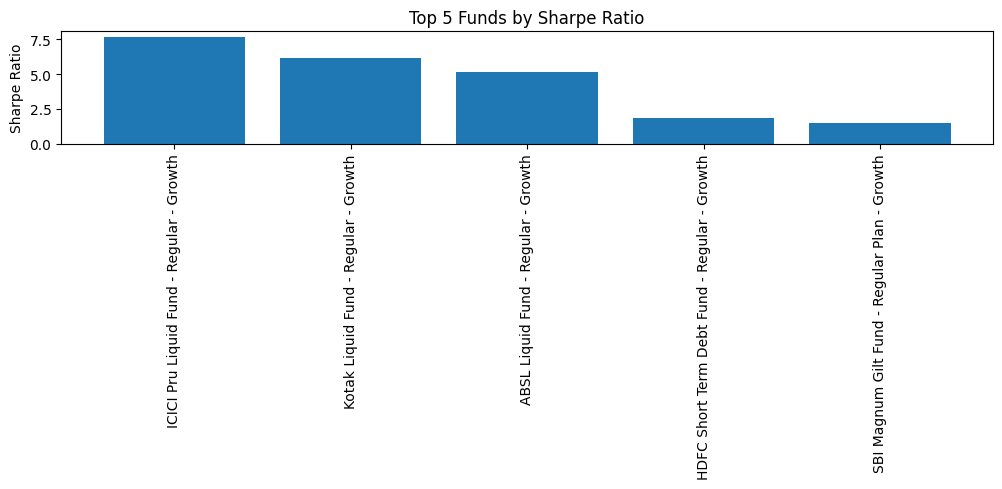

In [7]:
top5_funds = scheme_perf.sort_values(
    by='sharpe_ratio',
    ascending=False
).head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5_funds['scheme_name'],
    top5_funds['sharpe_ratio']
)

plt.xticks(rotation=90)
plt.title("Top 5 Funds by Sharpe Ratio")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()
plt.show()

rolling_sharpe_chart.png saved successfully


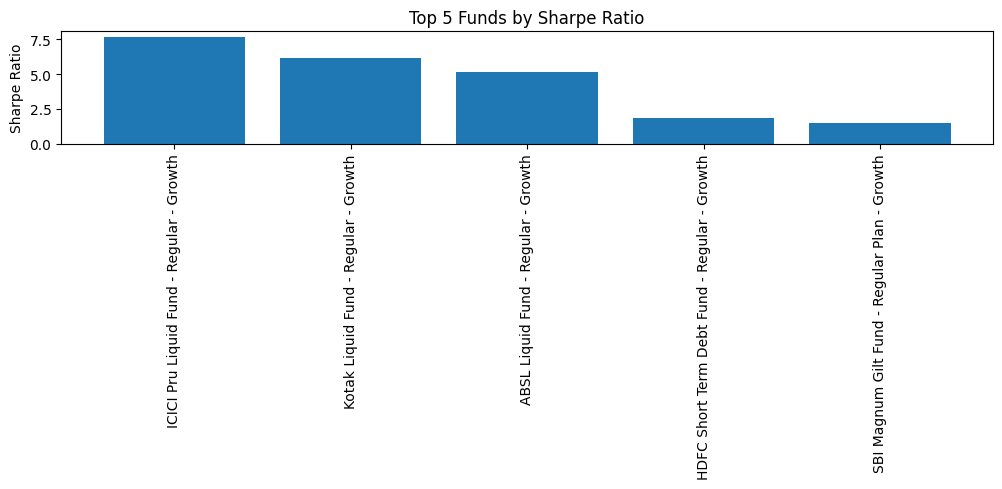

In [8]:
plt.figure(figsize=(10,5))

plt.bar(
    top5_funds['scheme_name'],
    top5_funds['sharpe_ratio']
)

plt.xticks(rotation=90)
plt.title("Top 5 Funds by Sharpe Ratio")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

print("rolling_sharpe_chart.png saved successfully")

In [9]:
investor_txn[['investor_id','transaction_date','amount_inr']].head()

,investor_id,transaction_date,amount_inr
0,INV003054,2024-01-01,1834
1,INV002952,2024-01-01,392882
2,INV003420,2024-01-01,912
3,INV003436,2024-01-01,1102
4,INV004691,2024-01-01,8682


In [10]:
investor_txn['transaction_date'] = pd.to_datetime(
    investor_txn['transaction_date']
)

investor_txn['cohort_year'] = (
    investor_txn.groupby('investor_id')['transaction_date']
    .transform('min')
    .dt.year
)

investor_txn[['investor_id','cohort_year']].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [11]:
cohort_analysis = investor_txn.groupby(
    'cohort_year'
).agg(
    avg_sip_amount=('amount_inr','mean'),
    total_invested=('amount_inr','sum'),
    investors=('investor_id','nunique')
).reset_index()

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [12]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully")

cohort_analysis.csv saved successfully


In [13]:
sip_counts = investor_txn.groupby(
    'investor_id'
).size().reset_index(name='sip_count')

eligible_investors = sip_counts[
    sip_counts['sip_count'] >= 6
]['investor_id']

sip_data = investor_txn[
    investor_txn['investor_id'].isin(eligible_investors)
].copy()

sip_data = sip_data.sort_values(
    ['investor_id', 'transaction_date']
)

sip_data['gap_days'] = sip_data.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,69.0
17587,INV000002,2024-10-03,101207,Lumpsum,203094,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,12.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,112.0


In [14]:
sip_continuity = sip_data.groupby(
    'investor_id'
).agg(
    avg_gap_days=('gap_days','mean')
).reset_index()

sip_continuity['status'] = np.where(
    sip_continuity['avg_gap_days'] > 35,
    'At Risk',
    'Healthy'
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000002,82.800000,At Risk
1,INV000004,53.375000,At Risk
2,INV000005,52.000000,At Risk
3,INV000006,99.000000,At Risk
4,INV000008,50.285714,At Risk


In [15]:
sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("sip_continuity.csv saved successfully")

sip_continuity.csv saved successfully


In [16]:
risk_level = "High"

recommended_funds = scheme_perf[
    scheme_perf['risk_grade'] == risk_level
].sort_values(
    by='sharpe_ratio',
    ascending=False
).head(3)

recommended_funds[
    ['scheme_name','risk_grade','sharpe_ratio']
]

,scheme_name,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
38,DSP Midcap Fund - Regular - Growth,High,0.90


In [17]:
sector_hhi = portfolio.groupby('amfi_code').apply(
    lambda x: (x['weight_pct'] ** 2).sum()
).reset_index(name='HHI')

sector_hhi = sector_hhi.merge(
    scheme_perf[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

sector_hhi.sort_values(
    by='HHI',
    ascending=False
).head()

,amfi_code,HHI,scheme_name
11,119092,2064.4767,Axis Bluechip Fund - Regular - Growth
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth
18,119599,1747.5096,SBI Small Cap Fund - Direct Plan - Growth
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,1682.9820,Nippon India Large Cap Fund - Regular - Growth


In [18]:
sector_hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

print("sector_hhi.csv saved successfully")

sector_hhi.csv saved successfully


# Advanced Analytics Insights

## Insight 1
Small Cap funds have the highest VaR and CVaR values, indicating higher downside risk.

## Insight 2
ICICI Pru Liquid Fund and Kotak Liquid Fund show the highest Sharpe Ratios among analyzed funds.

## Insight 3
The 2024 investor cohort contributes the majority of investments and investor participation.

## Insight 4
Many investors have average SIP gaps above 35 days and are classified as At Risk.

## Insight 5
Axis Bluechip Fund and ABSL Small Cap Fund have high HHI values, indicating concentrated portfolios.